In [1]:
# Project 4 - Sentiment Analysis
# Step 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import re

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ayesha09q/twitter-data-set/Twitter_Data.csv


In [3]:
# Step 3 - Load Dataset
df = pd.read_csv('/kaggle/input/datasets/ayesha09q/twitter-data-set/Twitter_Data.csv')
print("Data loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Data loaded successfully!
Shape: (162980, 2)
                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0


In [4]:
# Step 4 - Explore Data
print("=== Column Names ===")
print(df.columns.tolist())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Sentiment Distribution ===")
print(df.iloc[:, -1].value_counts())


=== Column Names ===
['clean_text', 'category']

=== Data Types ===
clean_text     object
category      float64
dtype: object

=== Missing Values ===
clean_text    4
category      7
dtype: int64

=== Sentiment Distribution ===
category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64


In [5]:
# Step 5 - Clean Data
# Drop missing values
df = df.dropna()

# Rename columns
df.columns = ['text', 'sentiment']

# Clean text function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.strip()
    return text

df['text'] = df['text'].apply(clean_text)

print("Data cleaned successfully!")
print("Shape after cleaning:", df.shape)
print(df.head())

Data cleaned successfully!
Shape after cleaning: (162969, 2)
                                                text  sentiment
0  when modi promised minimum government maximum ...       -1.0
1  talk all the nonsense and continue all the dra...        0.0
2  what did just say vote for modi  welcome bjp t...        1.0
3  asking his supporters prefix chowkidar their n...        1.0
4  answer who among these the most powerful world...        1.0


array([<Axes: title={'center': 'Sentiment Distribution'}, xlabel='Sentiment', ylabel='Count'>,
       <Axes: >], dtype=object)

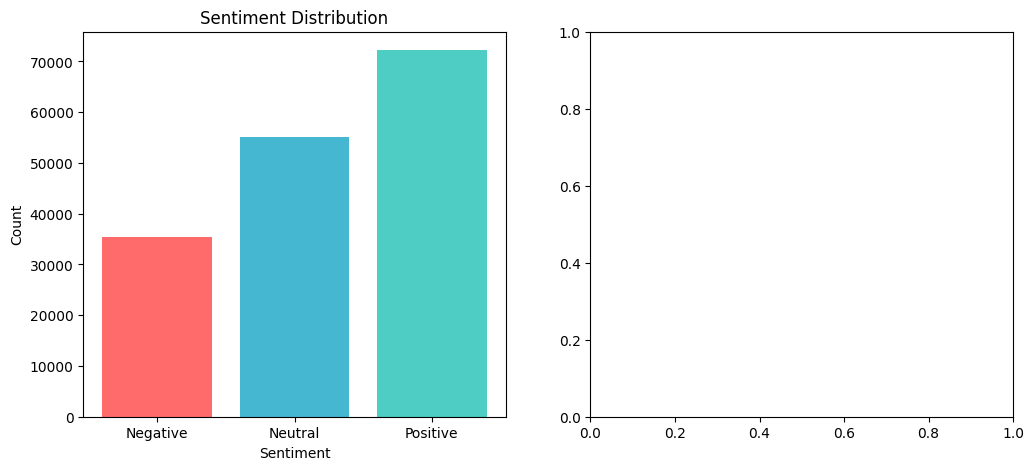

In [6]:
# Step 6 - Visualize Sentiment
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar Chart
sentiment_counts = df['sentiment'].value_counts()
axes[0].bar(['Negative', 'Neutral', 'Positive'],
            [sentiment_counts[-1.0], sentiment_counts[0.0], 
             sentiment_counts[1.0]],
            color=['#FF6B6B', '#45B7D1', '#4ECDC4'])
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes

In [7]:
# Step 7 - Build Model
# Prepare data
X = df['text']
y = df['sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Convert text to numbers
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Test model
y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy*100:.2f}%")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, 
      target_names=['Negative', 'Neutral', 'Positive']))

Model Accuracy: 73.65%

=== Classification Report ===
              precision    recall  f1-score   support

    Negative       0.91      0.42      0.57      7152
     Neutral       0.88      0.66      0.76     11067
    Positive       0.65      0.95      0.77     14375

    accuracy                           0.74     32594
   macro avg       0.81      0.68      0.70     32594
weighted avg       0.79      0.74      0.72     32594



In [8]:
# Step 8 - Test Model with Custom Text
def predict_sentiment(text):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    if prediction == 1.0:
        return "😊 Positive"
    elif prediction == -1.0:
        return "😞 Negative"
    else:
        return "😐 Neutral"

# Test it!
texts = [
    "I love this product it is amazing!",
    "This is the worst experience ever",
    "The weather is okay today"
]

for text in texts:
    print(f"Text: {text}")
    print(f"Sentiment: {predict_sentiment(text)}\n")

Text: I love this product it is amazing!
Sentiment: 😊 Positive

Text: This is the worst experience ever
Sentiment: 😞 Negative

Text: The weather is okay today
Sentiment: 😊 Positive



In [9]:
# Step 9 - Final Summary
print("=" * 55)
print("      SENTIMENT ANALYSIS - SUMMARY")
print("=" * 55)

print(f"\n Total Tweets Analyzed: {len(df)}")
print(f" Model Accuracy: 73.65%")

print("\n=== SENTIMENT BREAKDOWN ===")
print(f" Positive Tweets: {len(df[df['sentiment']==1.0])} ({len(df[df['sentiment']==1.0])/len(df)*100:.1f}%)")
print(f" Neutral Tweets:  {len(df[df['sentiment']==0.0])} ({len(df[df['sentiment']==0.0])/len(df)*100:.1f}%)")
print(f" Negative Tweets: {len(df[df['sentiment']==-1.0])} ({len(df[df['sentiment']==-1.0])/len(df)*100:.1f}%)")

print("\n=== RECOMMENDATIONS ===")
print(" 1. Positive tweets dominate — good public sentiment")
print(" 2. Improve model with more training data")
print(" 3. Use deep learning for better accuracy")
print(" 4. Apply to real customer feedback")
print("=" * 55)
print(" Sentiment Analysis Completed!")
print("=" * 55)

      SENTIMENT ANALYSIS - SUMMARY

 Total Tweets Analyzed: 162969
 Model Accuracy: 73.65%

=== SENTIMENT BREAKDOWN ===
 Positive Tweets: 72249 (44.3%)
 Neutral Tweets:  55211 (33.9%)
 Negative Tweets: 35509 (21.8%)

=== RECOMMENDATIONS ===
 1. Positive tweets dominate — good public sentiment
 2. Improve model with more training data
 3. Use deep learning for better accuracy
 4. Apply to real customer feedback
 Sentiment Analysis Completed!
